# Задача 1: Лингвистика и синтаксический разбор

> #### Функции вынесены в отдельный файл funcs.py

## Импорт библиотек

In [27]:
# Стандартные библиотеки
from collections import Counter

# Выделенные функции
from funcs import *

# Библиотеки для визуализации
import pandas as pd
from tqdm import tqdm

# Лингвистические библиотеки
import spacy


## Загрузка данных

In [28]:
# df = load_texts('data/lenta.db')


# texts_demo.csv включает в себя текст 100 статей
df = pd.read_csv('data/texts_demo.csv')
df


,text
0,"Microsoftопровергла сведения, что она собирает..."
1,"Астрономы предложили гипотезу, описывающую эво..."
2,Десятилетний мальчик (его имя не называется) п...
3,"Песня группы The Beatles ""Hey Jude"" на данный ..."
4,IPO (первичное размещение акций на бирже) Пром...
...,...
95,Следователь главного следственного управления ...
96,"Хоккеисты хабаровского ""Амура"" забросили две ш..."
97,"В крупнейшей российской социальной сети ""ВКонт..."
98,Граждане ФРГ подали 244 тысячи 237 протестов в...


## Инициализация инструментов

In [29]:
# Инициализация spacy
nlp = spacy.load("ru_core_news_md")
type(nlp)

spacy.lang.ru.Russian

In [30]:
# Чисти-чисти
tqdm.pandas()
print('Чистим данные')
df['clean_text'] = df['text'].progress_apply(clean_text)
df['clean_text'].head()

Чистим данные


100%|██████████| 100/100 [00:00<00:00, 3447.45it/s]


0    Microsoft опровергла сведения, что она собирае...
1    Астрономы предложили гипотезу, описывающую эво...
2    Десятилетний мальчик (его имя не называется) п...
3    Песня группы The Beatles "Hey Jude" на данный ...
4    IPO (первичное размещение акций на бирже) Пром...
Name: clean_text, dtype: str

## Синтаксический разбор предложений и разбиение на пары подлежащее/сказуемое

In [31]:
print("Чтобы было видно progress-bar")
df['pairs'] = multithread_spacy_proccesing(df['clean_text'], nlp)

Чтобы было видно progress-bar


Обработка: 100%|██████████| 100/100 [01:13<00:00,  1.36it/s]


In [32]:
df['pairs'].head()

0    [(microsoft, опровергнуть), (представитель, за...
1    [(астроном, предложить), (учёный, находить), (...
2    [(мальчик, позвонить), (инцидент, произойти), ...
3    [(песня, являться), (композиция, занимать), (п...
4    [(президент, заявить), (приём, начинать), (он,...
Name: pairs, dtype: object

## Зависимости совместных употреблений

In [33]:
all_pairs = [] # Все кортежи подлежащее/сказуемое
for pair_list in df['pairs']:
    all_pairs.extend(pair_list)

counter = Counter(all_pairs)

top_20 = counter.most_common(20)

print("ТОП 20 самых частых пар (Подлежащее, Сказуемое):")
print(f"{'#':<3} | {'Подлежащее':<20} | {'Сказуемое':<20} | {'Частота'}")
print("-" * 60)

for i, ((subj, verb), count) in enumerate(top_20, 1):
    print(f"{i:<3} | {subj:<20} | {verb:<20} | {count}")

ТОП 20 самых частых пар (Подлежащее, Сказуемое):
#   | Подлежащее           | Сказуемое            | Частота
------------------------------------------------------------
1   | выбор                | состояться           | 4
2   | инцидент             | произойти            | 3
3   | он                   | являться             | 3
4   | он                   | заявить              | 3
5   | министр              | заявить              | 3
6   | человек              | погибнуть            | 3
7   | речь                 | идти                 | 3
8   | он                   | объяснить            | 3
9   | суд                  | приговорить          | 3
10  | представитель        | заявить              | 2
11  | информация           | появляться           | 2
12  | он                   | подчеркнуть          | 2
13  | песков               | рассказать           | 2
14  | курс                 | опуститься           | 2
15  | человек              | посетить             | 2
16  | агентство"инте

## Визуализация результатов

C:\Users\Qweeck\MLProj\nlp-llm\funcs.py:177: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_viz, x='Count', y='Label', palette='YlOrRd')


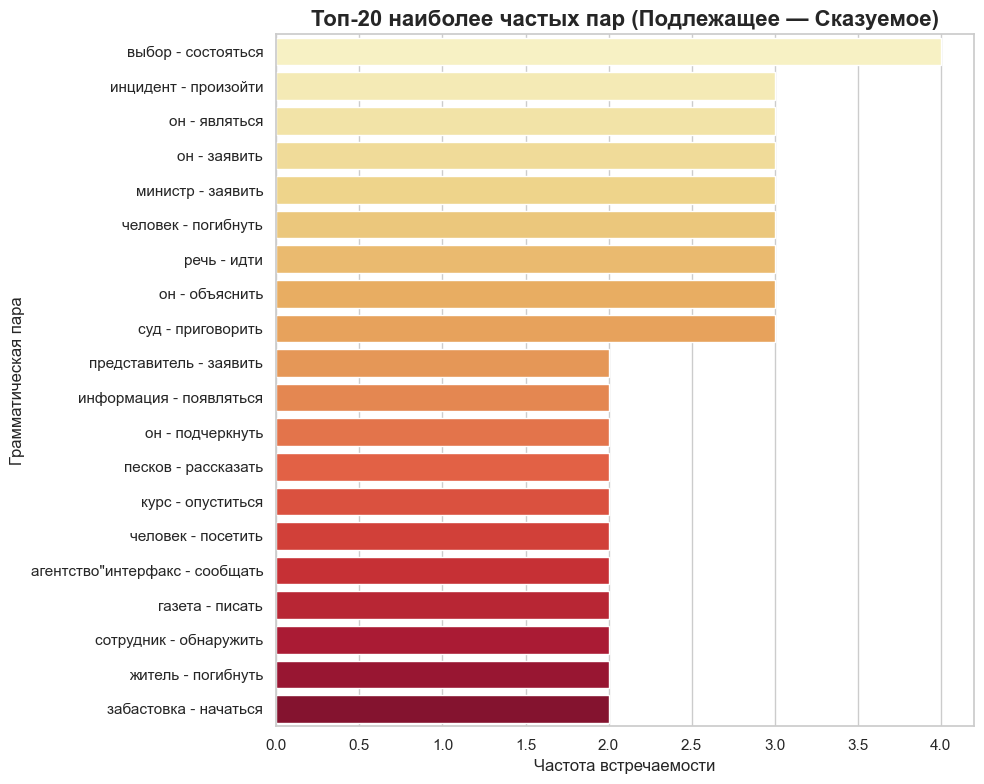

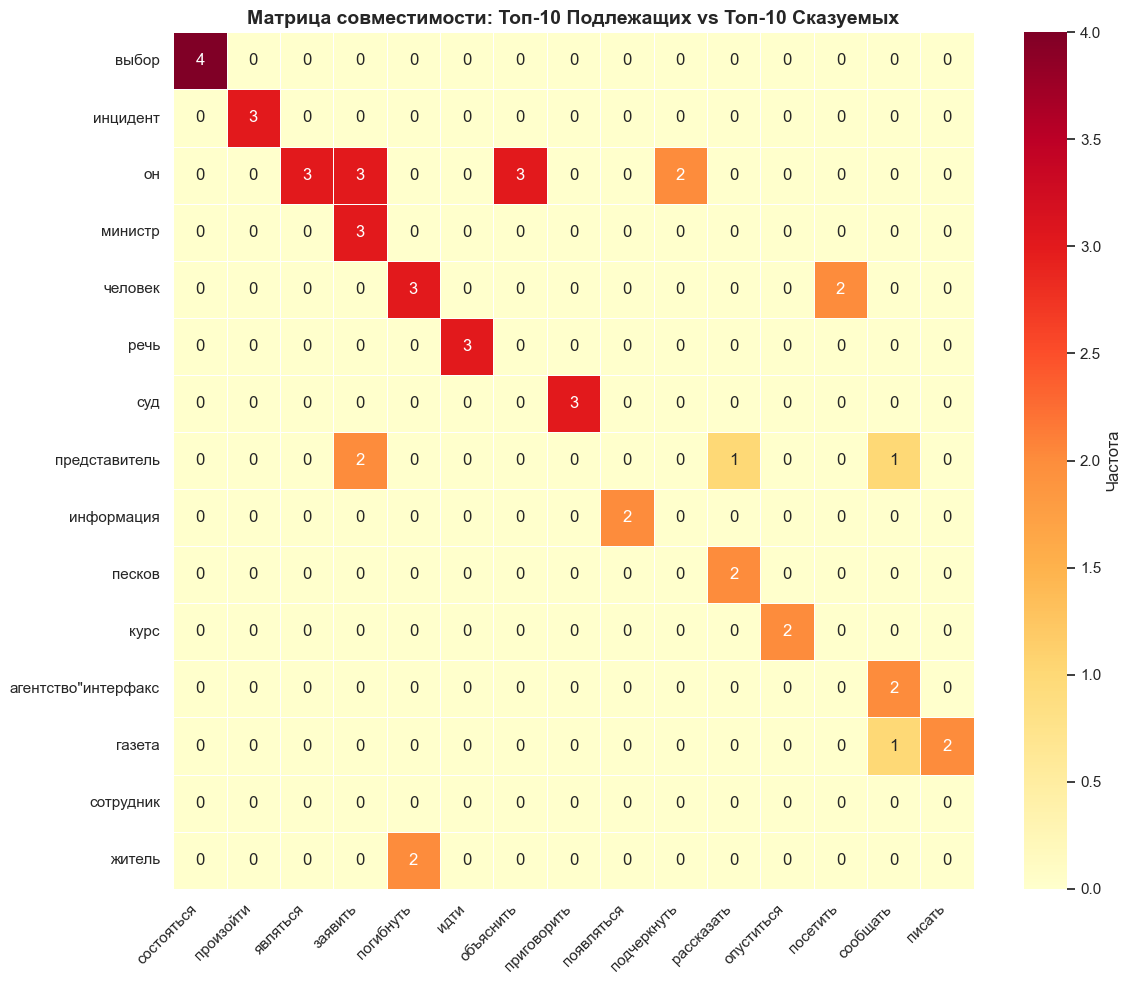

In [34]:
vizualization(counter)